# Zero-DCE++ with SE-Block — v3 (Improved Training)

**Improvements over v2:**

| # | Change | Fixes |
|---|---|---|
| 1 | **Early stopping** (patience=25) | Prevents overfitting, stops wasted epochs |
| 2 | **TV loss on enhanced image** (`L_tv_enh`) | Directly suppresses noise in output |
| 3 | **Aspect-ratio-preserving resize** | Fixes blocky colour artifacts |
| 4 | **Gradient accumulation** (×4 steps) | Smooths spiky training loss curve |
| 5 | **Bilateral filter** at inference | Extra denoising for real-world photos |


### 1. Imports

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import cv2
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')


Device: cuda
GPU: NVIDIA GeForce RTX 3060


### 2. SE-Block (unchanged)

In [2]:
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.shape
        w = self.pool(x).view(b, c)
        w = self.fc(w).view(b, c, 1, 1)
        return x * w

print('SE-Block defined')


SE-Block defined


### 3. DCENet (unchanged)

In [3]:
class DCENet(nn.Module):
    def __init__(self, use_attention=True):
        super().__init__()
        self.use_attention = use_attention
        self.conv1 = nn.Conv2d(3,  32, 3, 1, 1)
        self.conv2 = nn.Conv2d(32, 32, 3, 1, 1)
        self.conv3 = nn.Conv2d(32, 32, 3, 1, 1)
        if use_attention:
            self.se = SEBlock(32, reduction=8)
        self.conv4 = nn.Conv2d(32, 32, 3, 1, 1)
        self.conv5 = nn.Conv2d(64, 32, 3, 1, 1)
        self.conv6 = nn.Conv2d(64, 32, 3, 1, 1)
        self.conv7 = nn.Conv2d(64, 24, 3, 1, 1)
        self.relu  = nn.ReLU(inplace=True)
        nn.init.normal_(self.conv7.weight, mean=0, std=0.01)
        nn.init.constant_(self.conv7.bias, 0)

    def forward(self, x):
        x1 = self.relu(self.conv1(x))
        x2 = self.relu(self.conv2(x1))
        x3 = self.relu(self.conv3(x2))
        if self.use_attention:
            x3 = self.se(x3)
        x4 = self.relu(self.conv4(x3))
        x5 = self.relu(self.conv5(torch.cat([x4, x3], 1)))
        x6 = self.relu(self.conv6(torch.cat([x5, x2], 1)))
        return torch.tanh(self.conv7(torch.cat([x6, x1], 1)))

def enhance_image_with_curves(x, alpha):
    enhanced = x.clone()
    for i in range(8):
        a_i = alpha[:, i*3:(i+1)*3, :, :]
        enhanced = enhanced + a_i * enhanced * (1 - enhanced)
    return torch.clamp(enhanced, 0, 1)

model = DCENet(use_attention=True).to(device)
print(f'Model: {sum(p.numel() for p in model.parameters()):,} parameters')


Model: 79,672 parameters


### 4. Loss Function — IMPROVEMENT 1: TV loss on enhanced image

Added `L_tv_enh`: Total Variation loss applied directly to the **enhanced output**.
This penalises pixel-level noise in the final image, not just the alpha maps.

```
L_total = L_spa + 10·L_exp + 5·L_col + 1600·L_tv_alpha + 500·L_tv_enh
```

- `L_tv_alpha` (weight 1600) — keeps alpha maps spatially smooth (original paper)
- `L_tv_enh`   (weight 500)  — keeps enhanced image smooth → suppresses noise


In [4]:
class ZeroDCELoss(nn.Module):
    """
    L_total = L_spa + 10*L_exp + 5*L_col + 1600*L_tv_alpha + 500*L_tv_enh
    L_tv_enh is NEW in v3: directly suppresses noise in the enhanced output.
    """
    def __init__(self, w_tv_enh=500):
        super().__init__()
        self.w_tv_enh = w_tv_enh

    def forward(self, enhanced, low, alpha):
        enh_g = (0.299*enhanced[:,0:1] + 0.587*enhanced[:,1:2] + 0.114*enhanced[:,2:3])
        low_g = (0.299*low[:,0:1]      + 0.587*low[:,1:2]      + 0.114*low[:,2:3])

        L_spa       = self._spatial_loss(enh_g, low_g)
        L_exp       = self._exposure_loss(enh_g)
        L_col       = self._color_loss(enhanced)
        L_tv_alpha  = self._tv_loss(alpha)          # smooths alpha maps
        L_tv_enh    = self._tv_loss(enhanced)       # NEW: smooths output image

        total = (L_spa
                 + 10   * L_exp
                 + 5    * L_col
                 + 1600 * L_tv_alpha
                 + self.w_tv_enh * L_tv_enh)
        return total, L_spa, L_exp, L_col, L_tv_alpha, L_tv_enh

    def _spatial_loss(self, enh, low):
        enh_d = torch.nn.functional.avg_pool2d(enh, 4)
        low_d = torch.nn.functional.avg_pool2d(low, 4)
        d_el = enh_d[:,:,:,1:] - enh_d[:,:,:,:-1]; d_ll = low_d[:,:,:,1:] - low_d[:,:,:,:-1]
        d_er = enh_d[:,:,:,:-1]- enh_d[:,:,:,1:];  d_lr = low_d[:,:,:,:-1]- low_d[:,:,:,1:]
        d_eu = enh_d[:,:,1:,:] - enh_d[:,:,:-1,:]; d_lu = low_d[:,:,1:,:] - low_d[:,:,:-1,:]
        d_ed = enh_d[:,:,:-1,:]- enh_d[:,:,1:,:];  d_ld = low_d[:,:,:-1,:]- low_d[:,:,1:,:]
        return (torch.mean(torch.pow(d_el-d_ll,2)) + torch.mean(torch.pow(d_er-d_lr,2)) +
                torch.mean(torch.pow(d_eu-d_lu,2)) + torch.mean(torch.pow(d_ed-d_ld,2)))

    def _exposure_loss(self, img):
        return torch.abs(torch.mean(torch.nn.functional.avg_pool2d(img, 16)) - 0.6)

    def _color_loss(self, img):
        mr,mg,mb = torch.mean(img[:,0]),torch.mean(img[:,1]),torch.mean(img[:,2])
        return torch.abs(mr-mg) + torch.abs(mg-mb) + torch.abs(mb-mr)

    def _tv_loss(self, t):
        return (torch.mean(torch.abs(t[:,:,:,:-1]-t[:,:,:,1:])) +
                torch.mean(torch.abs(t[:,:,:-1,:]-t[:,:,1:,:])))

loss_fn = ZeroDCELoss(w_tv_enh=500).to(device)
print('Loss function defined')
print('  Terms: L_spa + 10*L_exp + 5*L_col + 1600*L_tv_alpha + 500*L_tv_enh')


Loss function defined
  Terms: L_spa + 10*L_exp + 5*L_col + 1600*L_tv_alpha + 500*L_tv_enh


### 5. Dataset — IMPROVEMENT 2: Aspect-ratio-preserving resize

**Root cause of blocky colour:** LOL-v2 images are 400×600 (portrait). The v2 code resized them to 614×614 (square), **stretching width by 53%**. This distorted the spatial colour distribution, which the model learned incorrectly → blocky colour at output.

**Fix:** Resize so the **short side = 614**, then random-crop 512×512. This preserves the original aspect ratio.


In [5]:
class LOLDataset(Dataset):
    """
    IMPROVEMENT 2: Aspect-ratio-preserving resize.
    Short side is scaled to resize_size; then we random/center crop.
    This prevents the squash distortion that caused blocky colour artifacts.
    """
    def __init__(self, image_pairs, img_size=512, augment=False):
        self.image_pairs = image_pairs
        self.img_size    = img_size
        self.augment     = augment
        self.resize_size = int(img_size * 1.15)  # short-side target

    def __len__(self):
        return len(self.image_pairs)

    def __getitem__(self, idx):
        pair = self.image_pairs[idx]
        low_img    = Image.open(pair['low']).convert('RGB')
        normal_img = Image.open(pair['normal']).convert('RGB')

        # ── FIXED: resize by short side, preserving aspect ratio ──
        # TF.resize with a single int resizes the shorter side to that value
        low_img    = TF.resize(low_img,    self.resize_size, interpolation=Image.BILINEAR)
        normal_img = TF.resize(normal_img, self.resize_size, interpolation=Image.BILINEAR)

        # ── Crop: same region for both images ──────────────────────
        if self.augment:
            # Random crop with same params for low+normal
            i, j, h, w = transforms.RandomCrop.get_params(
                low_img, (self.img_size, self.img_size))
            low_img    = TF.crop(low_img,    i, j, h, w)
            normal_img = TF.crop(normal_img, i, j, h, w)
            # Random horizontal flip (same for both)
            if torch.rand(1) > 0.5:
                low_img    = TF.hflip(low_img)
                normal_img = TF.hflip(normal_img)
        else:
            low_img    = TF.center_crop(low_img,    self.img_size)
            normal_img = TF.center_crop(normal_img, self.img_size)

        return {
            'low':      TF.to_tensor(low_img),
            'normal':   TF.to_tensor(normal_img),
            'filename': pair['filename']
        }

def load_image_pairs(data_path):
    low_p  = data_path / 'Low'
    norm_p = data_path / 'Normal'
    lows   = sorted([f for f in os.listdir(low_p)  if f.endswith(('.jpg','.png'))])
    norms  = sorted([f for f in os.listdir(norm_p) if f.endswith(('.jpg','.png'))])
    assert len(lows)==len(norms), f'Pair mismatch: {len(lows)} vs {len(norms)}'
    return [{'low':str(low_p/l),'normal':str(norm_p/n),'filename':l}
            for l,n in zip(lows,norms)]

BASE_PATH   = Path('LOL-v2')
train_pairs = load_image_pairs(BASE_PATH / 'Real_captured' / 'Train')
test_pairs  = load_image_pairs(BASE_PATH / 'Real_captured' / 'Test')
print(f'LOL-v2: {len(train_pairs)} train, {len(test_pairs)} test')

BATCH_SIZE  = 8
IMG_SIZE    = 512
train_loader = DataLoader(LOLDataset(train_pairs, IMG_SIZE, augment=True),
                          batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader  = DataLoader(LOLDataset(test_pairs,  IMG_SIZE, augment=False),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')


LOL-v2: 689 train, 100 test
Train batches: 87 | Test batches: 13


### 6. Training — IMPROVEMENT 3 & 4: Early Stopping + Gradient Accumulation

**Early stopping (patience=25):** If loss doesn't improve for 25 consecutive epochs, training stops automatically. The best checkpoint is always saved.

**Gradient accumulation (steps=4):** Instead of updating weights every batch, gradients are accumulated over 4 batches before an optimizer step. Effective batch size = 8×4 = **32**, which dramatically smooths the loss curve without needing more GPU memory.


In [6]:
LEARNING_RATE  = 1e-4
WEIGHT_DECAY   = 1e-4
NUM_EPOCHS     = 200
PATIENCE       = 25   # early stopping patience
ACCUM_STEPS    = 4    # gradient accumulation steps (effective batch = 8*4 = 32)
CHECKPOINT     = 'best_zerodce_seblock_v3.pth'

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-7)

history = {'loss':[],'spa':[],'exp':[],'col':[],'tv_a':[],'tv_enh':[],'lr':[]}
best_loss    = float('inf')
no_improve   = 0          # early stopping counter
stopped_epoch = NUM_EPOCHS

print(f"{'='*60}")
print(f'TRAINING v3 — max {NUM_EPOCHS} epochs, patience={PATIENCE}')
print(f'Effective batch size: {BATCH_SIZE} × {ACCUM_STEPS} = {BATCH_SIZE*ACCUM_STEPS}')
print(f"{'='*60}")

for epoch in range(NUM_EPOCHS):
    model.train()
    totals = dict(loss=0,spa=0,exp=0,col=0,tv_a=0,tv_enh=0)

    optimizer.zero_grad()        # zero once before accumulation loop
    pbar = tqdm(enumerate(train_loader), total=len(train_loader),
                desc=f'[{epoch+1}/{NUM_EPOCHS}]')

    for step, batch in pbar:
        low_imgs = batch['low'].to(device)

        alpha    = model(low_imgs)
        enhanced = enhance_image_with_curves(low_imgs, alpha)
        loss, L_spa, L_exp, L_col, L_tv_a, L_tv_enh = loss_fn(enhanced, low_imgs, alpha)

        # ── IMPROVEMENT 4: gradient accumulation ──────────────────
        # Divide loss so accumulated gradients equal a single large batch
        (loss / ACCUM_STEPS).backward()

        if (step + 1) % ACCUM_STEPS == 0 or (step + 1) == len(train_loader):
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.1)
            optimizer.step()
            optimizer.zero_grad()

        totals['loss']   += loss.item()
        totals['spa']    += L_spa.item()
        totals['exp']    += L_exp.item()
        totals['col']    += L_col.item()
        totals['tv_a']   += L_tv_a.item()
        totals['tv_enh'] += L_tv_enh.item()
        pbar.set_postfix({'loss': f"{loss.item():.4f}"})

    n = len(train_loader)
    avg_loss = totals['loss'] / n
    for k in history:
        if k == 'lr':
            history['lr'].append(optimizer.param_groups[0]['lr'])
        else:
            history[k].append(totals.get(k, 0) / n)

    # ── IMPROVEMENT 3: early stopping ─────────────────────────────
    if avg_loss < best_loss:
        best_loss  = avg_loss
        no_improve = 0
        torch.save(model.state_dict(), CHECKPOINT)
        print(f'  Epoch {epoch+1}: loss={avg_loss:.6f}  [BEST — saved]')
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            stopped_epoch = epoch + 1
            print(f'\n  Early stopping at epoch {stopped_epoch} '
                  f'(no improvement for {PATIENCE} epochs)')
            break

    if (epoch + 1) % 25 == 0:
        print(f'  Checkpoint epoch {epoch+1} | no_improve={no_improve}/{PATIENCE}')

    scheduler.step()

print(f"\n{'='*60}")
print(f'TRAINING COMPLETE — best loss: {best_loss:.6f}')
print(f'Stopped at epoch: {stopped_epoch}')
print(f"{'='*60}")


TRAINING v3 — max 200 epochs, patience=25
Effective batch size: 8 × 4 = 32


[1/200]: 100%|██████████| 87/87 [01:28<00:00,  1.02s/it, loss=29.4105]


  Epoch 1: loss=16.283350  [BEST — saved]


[2/200]: 100%|██████████| 87/87 [00:42<00:00,  2.07it/s, loss=7.9086] 


  Epoch 2: loss=12.834644  [BEST — saved]


...

  Epoch 194: loss=6.019773  [BEST — saved]


[195/200]: 100%|██████████| 87/87 [00:41<00:00,  2.08it/s, loss=6.0125]


  Epoch 195: loss=6.019668  [BEST — saved]


[200/200]: 100%|██████████| 87/87 [00:41<00:00,  2.08it/s, loss=6.0151]

  Checkpoint epoch 200 | no_improve=5/25

TRAINING COMPLETE — best loss: 6.019668
Stopped at epoch: 200


### 7. Training Curves

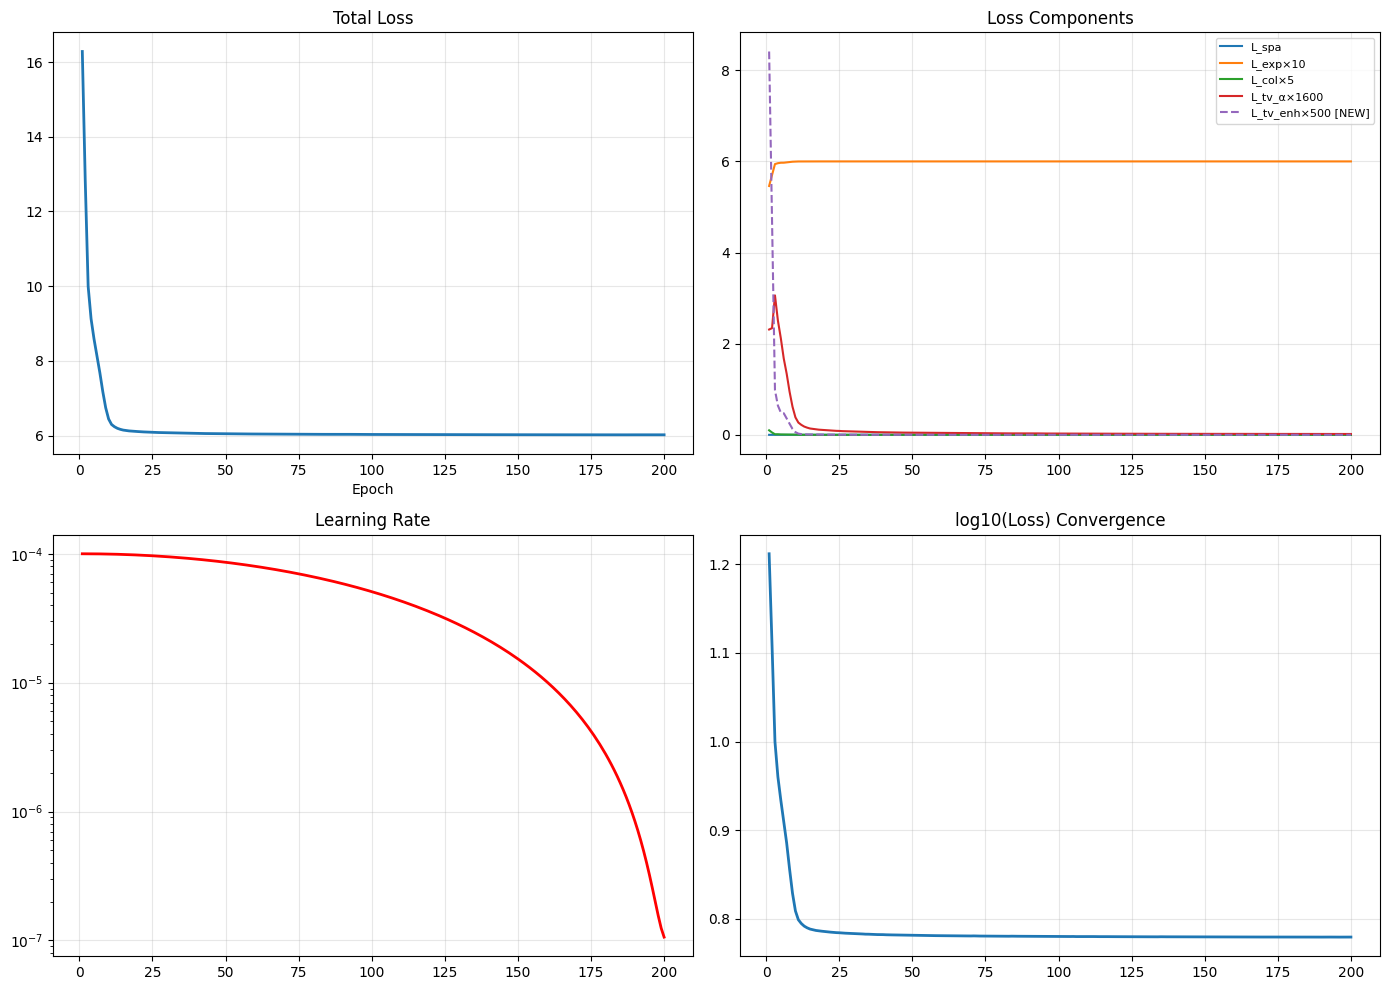

Saved: training_history_v3.png


In [7]:
ep = range(1, len(history['loss'])+1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(ep, history['loss'], linewidth=2)
axes[0,0].set_title('Total Loss'); axes[0,0].grid(True, alpha=0.3)
axes[0,0].set_xlabel('Epoch')

axes[0,1].plot(ep, history['spa'],                         label='L_spa')
axes[0,1].plot(ep, np.array(history['exp'])*10,            label='L_exp×10')
axes[0,1].plot(ep, np.array(history['col'])*5,             label='L_col×5')
axes[0,1].plot(ep, np.array(history['tv_a'])*1600,         label='L_tv_α×1600')
axes[0,1].plot(ep, np.array(history['tv_enh'])*500, '--',  label='L_tv_enh×500 [NEW]')
axes[0,1].set_title('Loss Components'); axes[0,1].legend(fontsize=8)
axes[0,1].grid(True, alpha=0.3)

axes[1,0].semilogy(ep, history['lr'], color='red', linewidth=2)
axes[1,0].set_title('Learning Rate'); axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(ep, np.log10(np.array(history['loss'])+1e-8), linewidth=2)
axes[1,1].set_title('log10(Loss) Convergence'); axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history_v3.png', dpi=150)
plt.show()
print('Saved: training_history_v3.png')


### 8. Inference — IMPROVEMENT 5: Bilateral filter for real-world photos

The bilateral filter removes remaining noise **while preserving edges**. It is applied AFTER the curve enhancement only when `denoise=True`.

- `d=9` — filter diameter (neighbourhood size)
- `sigma_color=75` — how much colour difference is allowed within the window
- `sigma_space=75` — how much spatial distance is allowed

Use `denoise=True` for your own real-world photos. For LOL-v2 test set evaluation, use `denoise=False` (don't want to alter metrics).


In [8]:
def enhance_single_image(image_path, checkpoint, denoise=False,
                          d=9, sigma_color=75, sigma_space=75):
    """
    Enhance a single image from disk.
    denoise=True  → apply bilateral filter after curve (recommended for real photos)
    denoise=False → raw curve output only (use for metric evaluation)
    """
    model_inf = DCENet(use_attention=True).to(device)
    model_inf.load_state_dict(torch.load(checkpoint, map_location=device))
    model_inf.eval()

    img = Image.open(image_path).convert('RGB')
    inp = TF.to_tensor(img).unsqueeze(0).to(device)

    with torch.no_grad():
        alpha    = model_inf(inp)
        enhanced = enhance_image_with_curves(inp, alpha)

    # Convert to numpy uint8 for display/save
    enh_np = (enhanced.squeeze(0).cpu().permute(1,2,0).numpy() * 255).astype(np.uint8)

    if denoise:
        # ── IMPROVEMENT 5: bilateral filter ───────────────────────
        # Works in BGR (OpenCV convention)
        enh_bgr    = cv2.cvtColor(enh_np, cv2.COLOR_RGB2BGR)
        enh_denoised = cv2.bilateralFilter(enh_bgr, d=d,
                                           sigmaColor=sigma_color,
                                           sigmaSpace=sigma_space)
        enh_np = cv2.cvtColor(enh_denoised, cv2.COLOR_BGR2RGB)

    orig_np = np.array(img)

    # ── Side-by-side comparison plot ──────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].imshow(orig_np);  axes[0].set_title('Original (low-light)'); axes[0].axis('off')
    axes[1].imshow(enh_np);   axes[1].set_title('Enhanced' + (' + Bilateral' if denoise else ''))
    axes[1].axis('off')
    plt.tight_layout()
    plt.savefig('inference_result.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: inference_result.png')
    return enh_np

# ── USAGE ─────────────────────────────────────────────────────────────────
# For your own real-world low-light photo:
# result = enhance_single_image('your_photo.jpg', 'best_zerodce_seblock_v3.pth', denoise=True)

# For LOL-v2 test images (no denoising — keeps metrics honest):
# result = enhance_single_image('lolv2_test.jpg', 'best_zerodce_seblock_v3.pth', denoise=False)

print('Inference function ready')
print('Usage: enhance_single_image("your_photo.jpg", "best_zerodce_seblock_v3.pth", denoise=True)')


Inference function ready
Usage: enhance_single_image("your_photo.jpg", "best_zerodce_seblock_v3.pth", denoise=True)


### 9. Batch Inference on LOL-v2 Test Set

In [9]:
def run_batch_inference(test_loader, checkpoint, output_dir='enhanced_v3', denoise=False):
    os.makedirs(output_dir, exist_ok=True)
    model_inf = DCENet(use_attention=True).to(device)
    model_inf.load_state_dict(torch.load(checkpoint, map_location=device))
    model_inf.eval()

    for batch in tqdm(test_loader, desc='Saving enhanced images'):
        low_imgs  = batch['low'].to(device)
        filenames = batch['filename']
        with torch.no_grad():
            alpha    = model_inf(low_imgs)
            enhanced = enhance_image_with_curves(low_imgs, alpha)
        for i, fname in enumerate(filenames):
            enh = (enhanced[i].cpu().permute(1,2,0).numpy()*255).astype(np.uint8)
            if denoise:
                bgr = cv2.cvtColor(enh, cv2.COLOR_RGB2BGR)
                bgr = cv2.bilateralFilter(bgr, 9, 75, 75)
                enh = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
            Image.fromarray(enh).save(os.path.join(output_dir, fname))
    print(f'Done — enhanced images saved to: {output_dir}/')

# run_batch_inference(test_loader, 'best_zerodce_seblock_v3.pth')
print('Batch inference function ready')


Batch inference function ready


---
### Summary of Changes vs v2

| # | What changed | Where | Why |
|---|---|---|---|
| 1 | `L_tv_enh` term added to loss (weight=500) | `ZeroDCELoss` | Directly suppresses pixel-level noise in output |
| 2 | Aspect-ratio-preserving resize (`TF.resize(img, short_side)`) | `LOLDataset` | Fixes blocky colour — 400×600 was being squashed to 614×614 |
| 3 | Early stopping (patience=25) | Training loop | Saves best checkpoint, stops when plateaued |
| 4 | Gradient accumulation (4 steps, effective batch=32) | Training loop | Smooths spiky loss curve without more GPU memory |
| 5 | `cv2.bilateralFilter` in inference | `enhance_single_image` | Edge-preserving denoising for real-world photos |
